# Hidden state, unrolling and `return_sequences`

**Learning objective:** Inspect per-timestep outputs and final state to understand what Keras returns from recurrent layers.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:25.312841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974805.327739    2948 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974805.332037    2948 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:26.972550: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
x=tf.constant(np.arange(2*5*3).reshape(2,5,3)/10, dtype=tf.float32)
layer=tf.keras.layers.SimpleRNN(4, return_sequences=True, return_state=True)
sequence_output, final_state=layer(x)
print("input:",x.shape); print("all hidden states:",sequence_output.shape); print("final state:",final_state.shape)
print("last sequence state equals final state:", np.allclose(sequence_output[:,-1,:].numpy(), final_state.numpy()))


input: (2, 5, 3)
all hidden states: (2, 5, 4)
final state: (2, 4)
last sequence state equals final state: True


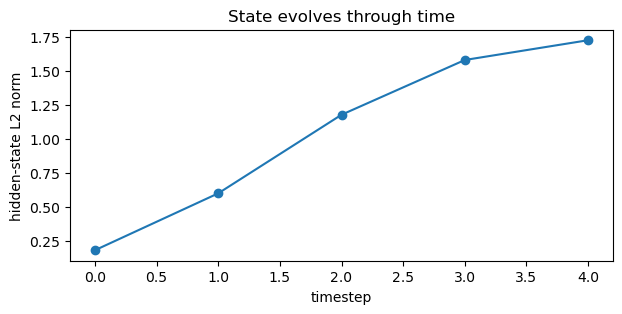

In [3]:
norms=tf.norm(sequence_output[0],axis=1).numpy()
plt.figure(figsize=(7,3)); plt.plot(norms,marker="o"); plt.xlabel("timestep"); plt.ylabel("hidden-state L2 norm"); plt.title("State evolves through time"); plt.show()


Use `return_sequences=True` when downstream layers need every timestep (stacked RNNs, sequence labeling, attention-like processing). Use the final representation for many-to-one tasks.
